## Project

## Exploring global literacy rates by age and gender using World Bank data

## How to use this notebook

1. Download or clone this repository from GitHub
2. Open `project.ipynb` in Jupyter Notebook
3. Run all cells from top to bottom
4. Results will be exported to the `exports/` folder

No API key or Kaggle account is needed.
The data file is included in the repository.

## Data Pipeline

![Data Pipeline](pipeline.png)

## Introduction

This project analyzes global literacy rates across three age groups Youth (15–24 years), Adults (25–64 years) and Elderly (65+ years) to determine how literacy rates differ by age group and gender. Global regions are also included in the analysis to show regional differences. 

The goal is to answer: What are the current differences in literacy rates globally based on gender, age group and global regions?

The original idea explored in assignment 2, was to analyze how literacy rates have developed during the recent decades around the world. However, the data didn't fully support this analysis since the data didn't include enough country values for the same years. Therefore, this project uses the most recent years per country where data was available and is focused on the current situation based on the data. The Kaggle data only goes until 2021 so we will use most recent data before that year.

Data source: World Bank Education Statistics (Kaggle)

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Loads the main dataset and country data
data = pd.read_csv("EdStatsData.csv", low_memory=False)
countries = pd.read_csv("EdStatsCountry.csv", low_memory=False)

print("Data shape:", data.shape)
display(data.head())

Data shape: (886930, 70)


,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# The data has thousands of variables so we will filter to use the indicators we want to analyze (3 age groups per male/female/both)
indicators = [
    "Youth literacy rate, population 15-24 years, both sexes (%)",
    "Youth literacy rate, population 15-24 years, male (%)",
    "Youth literacy rate, population 15-24 years, female (%)",
    "Literacy rate, population 25-64 years, both sexes (%)",
    "Literacy rate, population 25-64 years, male (%)",
    "Literacy rate, population 25-64 years, female (%)",
    "Elderly literacy rate, population 65+ years, both sexes (%)",
    "Elderly literacy rate, population 65+ years, male (%)",
    "Elderly literacy rate, population 65+ years, female (%)",
]

# Keeps only countries because regional aggregates have no Region in EdStatsCountry data
real_countries = countries[countries["Region"].notna()][["Country Code", "Region"]]

# Filters to our indicators and merge with region info
literacy = data[data["Indicator Name"].isin(indicators)].copy()
literacy = literacy.merge(real_countries, on="Country Code")

print("Rows after filtering:", len(literacy))
display(literacy.head())

Rows after filtering: 1926


,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69,Region
0,Afghanistan,AFG,"Elderly literacy rate, population 65+ years, b...",UIS.LR.AG65,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,South Asia
1,Afghanistan,AFG,"Elderly literacy rate, population 65+ years, f...",UIS.LR.AG65.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,South Asia
2,Afghanistan,AFG,"Elderly literacy rate, population 65+ years, m...",UIS.LR.AG65.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,South Asia
3,Afghanistan,AFG,"Literacy rate, population 25-64 years, both se...",UIS.LR.AG25T64,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,South Asia
4,Afghanistan,AFG,"Literacy rate, population 25-64 years, female (%)",UIS.LR.AG25T64.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,South Asia


In [46]:
# Years available in the dataset
year_cols = [str(y) for y in range(1970, 2021) if str(y) in literacy.columns]

# Gets the most recent non-null value for each country
def get_latest_value(row):
    for year in reversed(year_cols):
        if pd.notna(row[year]):
            return row[year], year
    return None, None

literacy["latest_value"], literacy["latest_year"] = zip(
    *literacy.apply(get_latest_value, axis=1)
)

# Drops rows with no data at all
literacy = literacy.dropna(subset=["latest_value"])

print("Countries with data:", literacy["Country Name"].nunique())
display(literacy[["Country Name", "Region", "Indicator Name", "latest_value", "latest_year"]].head(10))

Countries with data: 164


,Country Name,Region,Indicator Name,latest_value,latest_year
0,Afghanistan,South Asia,"Elderly literacy rate, population 65+ years, b...",20.32185,2011
1,Afghanistan,South Asia,"Elderly literacy rate, population 65+ years, f...",19.67049,2011
2,Afghanistan,South Asia,"Elderly literacy rate, population 65+ years, m...",11.35688,1979
3,Afghanistan,South Asia,"Literacy rate, population 25-64 years, both se...",23.15362,2011
4,Afghanistan,South Asia,"Literacy rate, population 25-64 years, female (%)",8.41276,2011
5,Afghanistan,South Asia,"Literacy rate, population 25-64 years, male (%)",37.79481,2011
6,Afghanistan,South Asia,"Youth literacy rate, population 15-24 years, b...",46.99005,2011
7,Afghanistan,South Asia,"Youth literacy rate, population 15-24 years, f...",32.11322,2011
8,Afghanistan,South Asia,"Youth literacy rate, population 15-24 years, m...",61.87907,2011
9,Albania,Europe & Central Asia,"Elderly literacy rate, population 65+ years, b...",86.91226,2012


In [47]:
# This saves the filtered raw data so that others can run the notebook without Kaggle
os.makedirs("exports", exist_ok=True)
literacy.to_csv("exports/literacy_raw.csv", index=False)
print("Raw data saved to exports/literacy_raw.csv")

Raw data saved to exports/literacy_raw.csv


In [48]:
# Creates a shorter label for each indicator to use in charts
label_map = {
    "Youth literacy rate, population 15-24 years, both sexes (%)": "Youth (both)",
    "Youth literacy rate, population 15-24 years, male (%)": "Youth (male)",
    "Youth literacy rate, population 15-24 years, female (%)": "Youth (female)",
    "Literacy rate, population 25-64 years, both sexes (%)": "Adult (both)",
    "Literacy rate, population 25-64 years, male (%)": "Adult (male)",
    "Literacy rate, population 25-64 years, female (%)": "Adult (female)",
    "Elderly literacy rate, population 65+ years, both sexes (%)": "Elderly (both)",
    "Elderly literacy rate, population 65+ years, male (%)": "Elderly (male)",
    "Elderly literacy rate, population 65+ years, female (%)": "Elderly (female)",
}

literacy["Age Group"] = literacy["Indicator Name"].map(label_map)

# Keeps only the columns we need
df = literacy[["Country Name", "Country Code", "Region", "Age Group", 
               "latest_value", "latest_year"]].copy()
df = df.rename(columns={"latest_value": "Literacy Rate", "latest_year": "Year"})

print("Clean dataset shape:", df.shape)
display(df.head(10))

Clean dataset shape: (1473, 6)


,Country Name,Country Code,Region,Age Group,Literacy Rate,Year
0,Afghanistan,AFG,South Asia,Elderly (both),20.32185,2011
1,Afghanistan,AFG,South Asia,Elderly (female),19.67049,2011
2,Afghanistan,AFG,South Asia,Elderly (male),11.35688,1979
3,Afghanistan,AFG,South Asia,Adult (both),23.15362,2011
4,Afghanistan,AFG,South Asia,Adult (female),8.41276,2011
5,Afghanistan,AFG,South Asia,Adult (male),37.79481,2011
6,Afghanistan,AFG,South Asia,Youth (both),46.99005,2011
7,Afghanistan,AFG,South Asia,Youth (female),32.11322,2011
8,Afghanistan,AFG,South Asia,Youth (male),61.87907,2011
9,Albania,ALB,Europe & Central Asia,Elderly (both),86.91226,2012


In [49]:
# Summary statistics by age group
summary = df.groupby("Age Group")["Literacy Rate"].describe()
display(summary)

,count,mean,std,min,25%,50%,75%,max
Age Group,,,,,,,,
Adult (both),163.0,80.064626,24.014638,13.27460,66.357750,93.375760,98.415410,100.0
Adult (female),163.0,76.147979,28.638863,7.02665,54.893885,91.934300,98.541320,100.0
Adult (male),163.0,84.335733,19.453475,21.09400,74.802375,94.839080,98.850645,100.0
Elderly (both),164.0,61.860117,30.782985,3.72468,34.740217,69.250540,91.245961,100.0
Elderly (female),164.0,54.828250,35.035849,0.40250,19.407565,60.347455,90.314732,100.0
Elderly (male),164.0,69.430338,27.922622,7.13478,48.332190,79.099880,94.320246,100.0
Youth (both),164.0,88.866980,16.916734,23.52378,85.534490,98.120830,99.276285,100.0
Youth (female),164.0,87.319695,19.965513,15.05777,83.070028,98.363365,99.401690,100.0
Youth (male),164.0,90.563559,13.882349,34.53362,86.994497,98.031080,99.309978,100.0


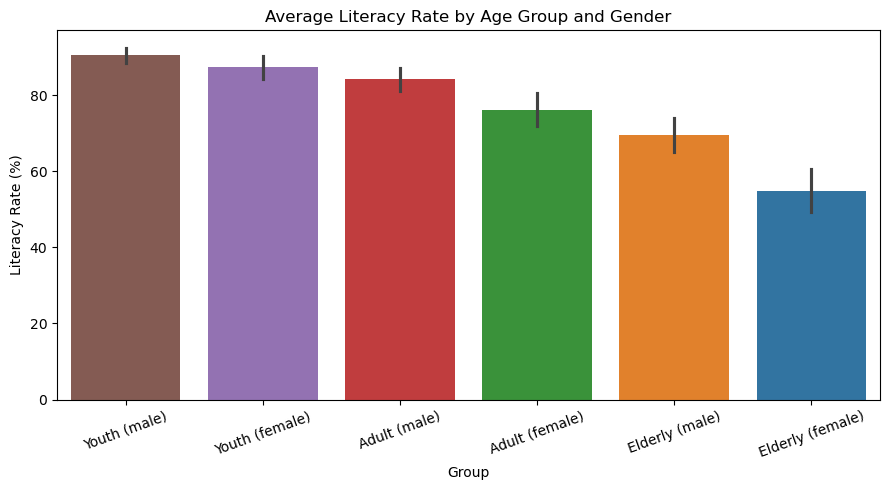

In [50]:
# Compares male vs female literacy across the three age groups
gender = df[~df["Age Group"].str.contains("both")]

plt.figure(figsize=(9, 5))
sns.barplot(data=gender, x="Age Group", y="Literacy Rate", hue="Age Group",
            order=["Youth (male)", "Youth (female)", 
                   "Adult (male)", "Adult (female)",
                   "Elderly (male)", "Elderly (female)"])
plt.title("Average Literacy Rate by Age Group and Gender")
plt.xlabel("Group")
plt.ylabel("Literacy Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

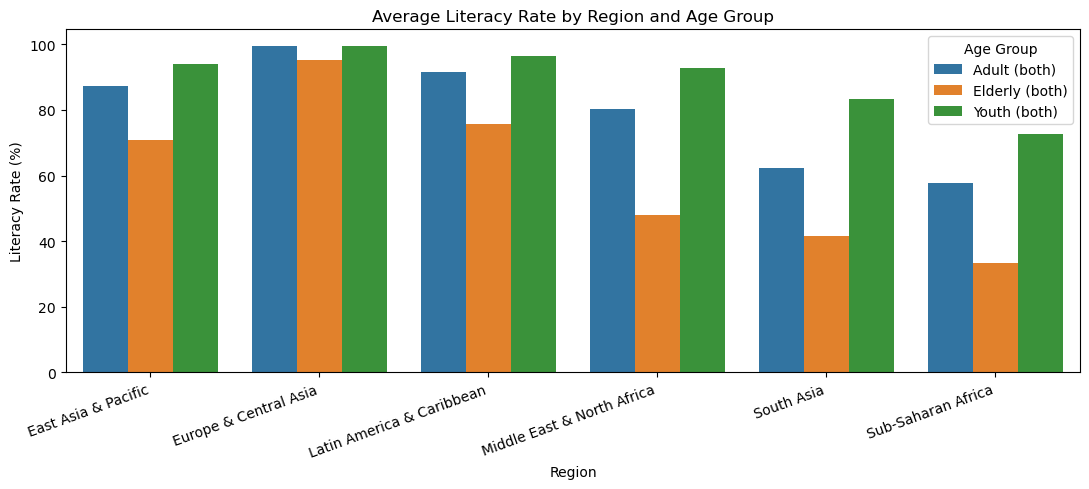

In [51]:
# Average literacy by region for each age group for both sexes
region_literacy = both_sexes.groupby(["Region", "Age Group"])["Literacy Rate"].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.barplot(data=region_literacy, x="Region", y="Literacy Rate", hue="Age Group")
plt.title("Average Literacy Rate by Region and Age Group")
plt.xlabel("Region")
plt.ylabel("Literacy Rate (%)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

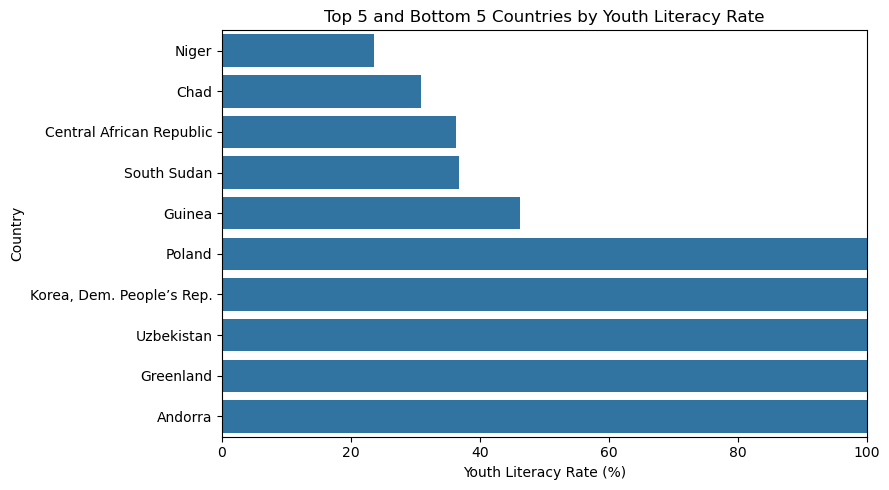

In [52]:
# Bottom 5 and top 5 countries by youth literacy rate
youth_both = df[df["Age Group"] == "Youth (both)"].sort_values("Literacy Rate")

bottom5 = youth_both.head(5)
top5 = youth_both.tail(5)
top_bottom = pd.concat([bottom5, top5])

plt.figure(figsize=(9, 5))
sns.barplot(data=top_bottom, x="Literacy Rate", y="Country Name")
plt.title("Top 5 and Bottom 5 Countries by Youth Literacy Rate")
plt.xlabel("Youth Literacy Rate (%)")
plt.ylabel("Country")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

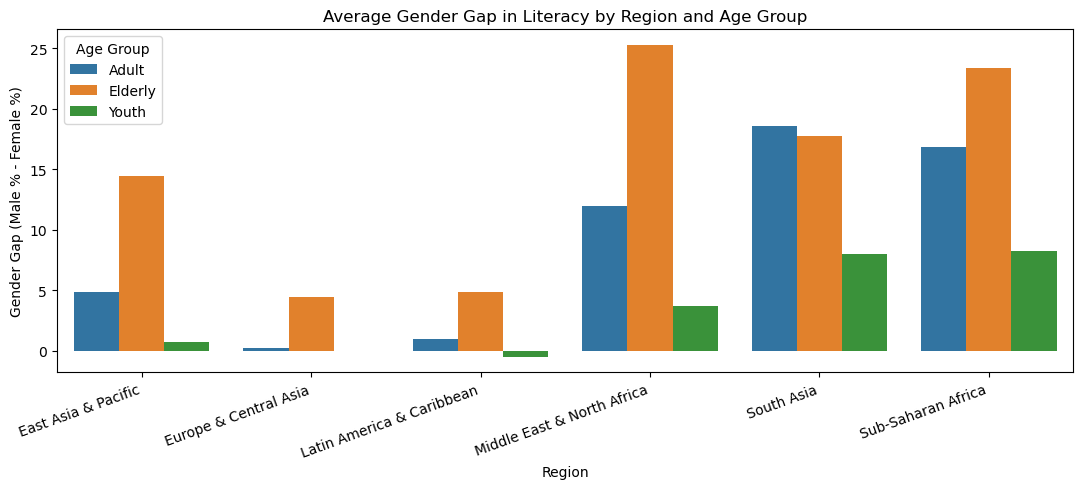

In [53]:
# Calculates the gender gap (male minus female) per country and age group
male = df[df["Age Group"].str.contains("male") & ~df["Age Group"].str.contains("female")]
female = df[df["Age Group"].str.contains("female")]

# Merges male and female on country and age group category
male = male.copy()
female = female.copy()
male["Group"] = male["Age Group"].str.extract(r"(\w+) \(male\)")
female["Group"] = female["Age Group"].str.extract(r"(\w+) \(female\)")

gap = male.merge(female, on=["Country Name", "Country Code", "Region", "Group"],
                 suffixes=("_male", "_female"))
gap["Gender Gap"] = gap["Literacy Rate_male"] - gap["Literacy Rate_female"]

# Average gender gap by region and age group
gap_summary = gap.groupby(["Region", "Group"])["Gender Gap"].mean().reset_index()

plt.figure(figsize=(11, 5))
sns.barplot(data=gap_summary, x="Region", y="Gender Gap", hue="Group")
plt.title("Average Gender Gap in Literacy by Region and Age Group")
plt.xlabel("Region")
plt.ylabel("Gender Gap (Male % - Female %)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

In [54]:
# Exports the final dataset
df.to_csv("exports/literacy_results.csv", index=False)
print("Results saved to exports/literacy_results.csv")

# Exports regional summary
region_literacy.to_csv("exports/literacy_by_region.csv", index=False)
print("Regional summary saved to exports/literacy_by_region.csv")

Results saved to exports/literacy_results.csv
Regional summary saved to exports/literacy_by_region.csv


## Conclusions and findings

  Based on the analysis, we can see that there are large differences between literacy geographically and based on age groups and gender, and that improvement has happended globally.

  Youth has the highest literacy rates globally, then adults and lastly elderly. This proves that there has been significant improvement in literacy. The gender gap also decreases from elderly to youth group showing that access to education has become more equal for women.

  The improvement in literacy rates has been highest in Africa and South Asia, and lower in Europe and Central Asia where the rates were quite high for elderly already. 

  The bottom 5 and top 5 countries per youth literacy showed interesting results especially for the top 5 countries. It's possible that population size or other facotrs lowere the data quality. 

### Statement of AI use

Claude was used to help with some of the technical parts of the project like exporting and importing the data correctly so that others can use this notebook without Keggle. The idea for this project, data source and what was analyzed was chosen by myself and AI was not used to plan/execute the project.